# Privacy Policy Clustering Analysis
This notebook demonstrates the complete machine learning pipeline fro clustering privcy policies using graph transformed yml files. It includes data transformation, exploratory data analysis (EDA), clustering and evaluation.

## 1. Dependency Installation

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn umap-learn plotly wordcloud PyYAML

# Imports and Setup

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
import seaborn as sns
import yaml
import os
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import umap
from sklearn.manifold import TSNE
import plotly.express as px
from scipy.sparse import hstack
import numpy as np

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


import pandas as pd:
Imports Pandas, a powerful library for data manipulation and analysis using dataframes.

import numpy as np:
Imports NumPy, a core library for numerical computations and handling arrays.

import os:
Imports Python’s built-in OS module for interacting with the operating system (e.g., file paths).

import yaml:
Used for reading and writing YAML configuration files, common for storing structured settings.

import matplotlib.pyplot as plt:
Provides a MATLAB-like interface for basic plotting (line graphs, bar charts, etc.).

from matplotlib.colors import ListedColormap:
Used to create custom color maps in plots.

import matplotlib.cm as cm:
Gives access to color maps (e.g., for heatmaps or continuous value visualization).

import seaborn as sns:
Imports Seaborn, a higher-level interface for statistical graphics built on top of Matplotlib.

import plotly.express as px:
Imports Plotly Express, a library for creating interactive visualizations (scatter plots, 3D plots, etc.).

from wordcloud import WordCloud:
Enables generation of word clouds, which are visual representations of text data.

from sklearn.feature_extraction.text import TfidfVectorizer:
Transforms text into TF-IDF features for text mining or classification.

from sklearn.preprocessing import OneHotEncoder:
Encodes categorical variables as binary vectors (one-hot encoding).

from sklearn.cluster import KMeans:
Loads the K-Means clustering algorithm for unsupervised learning.

from sklearn.decomposition import TruncatedSVD:
Used for dimensionality reduction, especially for sparse matrices (e.g., from TF-IDF).

from sklearn.manifold import TSNE:
A nonlinear dimensionality reduction technique for visualizing high-dimensional data in 2D or 3D.

import umap:
Imports UMAP, another powerful dimensionality reduction technique used for clustering and visualization.

from scipy.sparse import hstack:
Combines sparse matrices horizontally (useful when dealing with TF-IDF or encoded features).



##  3. Data Transformation

In [3]:
def transform_graphs():
    import os
    import yaml
    import pandas as pd

    def extract_graph_data(filepath, app_name):
        with open(filepath, 'r') as f:
            graph = yaml.safe_load(f)
        data = []
        for link in graph.get("links", []):
            source = link.get("source", "")
            target = link.get("target", "")
            relation = link.get("key", "")
            texts = link.get("text", [])
            purpose_dict = link.get("purposes", {})
            categories = [k for k, v in purpose_dict.items() if v]
            category_str = ', '.join(categories) if categories else 'unspecified'
            purpose_list = [p for p_group in purpose_dict.values() for p in p_group] if purpose_dict else ["unspecified"]
            purpose_str = ', '.join(purpose_list)
            for text in texts:
                data.append({
                    "App": app_name,
                    "Source": source,
                    "Relation": relation,
                    "Target": target,
                    "Example Text": text,
                    "Purpose Categories": category_str,
                    "Purpose Details": purpose_str
                })
        return data

    # Updated to look inside 'graph files/' folder
    folder_path = "/content/drive/My Drive/DSMLProject/Code/graphfiles"
    file_paths = {
        os.path.splitext(f)[0]: os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.endswith(".yml")
    }

    combined_data = []
    for app_name, filename in file_paths.items():
        combined_data.extend(extract_graph_data(filename, app_name))

    df = pd.DataFrame(combined_data)
    df.to_csv("privacy_policy_data.csv", index=False)
    print(" Saved as privacy_policy_data.csv")



This transform_graphs() function is designed to extract structured data from a collection of YAML graph files (likely representing relationships in privacy policies or app permissions) and convert it into a CSV file for analysis.

 Nested Function: extract_graph_data(filepath, app_name)
Opens a YAML file (.yml) and reads its contents into a dictionary (graph).

Extracts "links" — which describe relationships between entities.

For each link, Pulls fields like:

source, target, key (renamed as Relation)

text (example descriptions)

purposes (a dictionary like {category: [details]})

Extracts:

Purpose categories (Purpose Categories): top-level keys in the purposes dict.

Purpose details (Purpose Details): individual values within those categories.

For each text, appends a row to a data list with:

App name, source/target, relation, example text, purpose categories, and purpose details.

2. File Collection
Looks for all .yml files in the folder:

swift
Copy
Edit
/content/drive/My Drive/DSMLProject/Code/graphfiles
Builds a dictionary:

python
Copy
Edit
{ app_name: full_path }
where app_name is the file name (without extension).

3. Data Aggregation
For each YAML file:

Calls extract_graph_data() to get rows for that app.

Appends those rows to a combined_data list.

4. Data Export
Converts the list of dictionaries (combined_data) into a Pandas DataFrame.

Saves it as privacy_policy_data.csv.

##  4.Exploratory Data Analysis (EDA)

In [4]:

def perform_eda():
    df = pd.read_csv('privacy_policy_data.csv')
    print(df.head())

    plt.figure(figsize=(10, 6))
    df['Relation'].value_counts().plot(kind='barh', color='skyblue')
    plt.title("Distribution of Relationship Types")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

    top_targets = df['Target'].value_counts().head(10)
    plt.figure(figsize=(10, 6))
    top_targets.plot(kind='barh', color='lightgreen')
    plt.title("Top 10 Most Collected Data Types")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 8))
    purpose_counts = df['Purpose Categories'].str.split(', ').explode().value_counts()
    purpose_counts.plot.pie(autopct='%1.1f%%', startangle=140)
    plt.title("Distribution of Data Use Purposes")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    text_blob = ' '.join(df['Example Text'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud of Example Policy Text")
    plt.tight_layout()
    plt.show()


This function performs Exploratory Data Analysis (EDA) on structured privacy policy data saved in the file privacy_policy_data.csv. It uses visualization to explore and summarize relationships, data collection types, purpose categories, and textual descriptions extracted from YAML graph files.

Reads the previously exported CSV into a DataFrame.

Displays the first five rows to provide an overview of the data.

Plots a horizontal bar chart of how often each data relationship (e.g., "collects", "shares") appears.

Gives insight into the nature of interactions described in privacy policies.

Displays the 10 most common data types (targets) mentioned across apps.

Useful for identifying which user data types are most frequently referenced.

Splits multi-valued purpose category fields (like "advertising, analytics") into individual items.

Plots a pie chart showing the proportion of each data usage purpose

Aggregates all policy "Example Text" fields into one string.

Uses WordCloud to visualize the most common words, offering a high-level sense of language used in privacy policies.

## 5. Clustering and Evaluation

1. Load and Clean Data
Loads a CSV file containing privacy policy records.

Focuses only on four columns:

Target: text field (e.g., data collected)

Purpose Categories, Relation, and Source: categorical metadata

Cleans the dataset by removing rows with missing values.

Replaces spaces in the Target column with underscores to help with tokenization during vectorization.

2. Feature Extraction
TF-IDF Vectorization:

Converts the Target text into numerical vectors based on term frequency-inverse document frequency. This captures the importance of words across documents.

One-Hot Encoding:

Transforms categorical columns into binary vectors.

Feature Combination:

Combines both types of features into one matrix using horizontal stacking (sparse matrix).

3. K-Means Clustering
Applies K-Means clustering with 3 clusters (n_clusters=3).

Assigns a cluster label to each data point and stores it in the DataFrame.

4. Dimensionality Reduction and Visualization
Truncated SVD:

Reduces the feature space to 2 dimensions to visualize the clusters as points in a 2D scatter plot.

Elbow Method:

Runs K-Means with k from 1 to 10 and records the "inertia" (i.e., within-cluster sum of squares).

Helps to choose the best number of clusters by looking for the "elbow point" where adding more clusters doesn’t significantly reduce the inertia.

t-SNE:

Adds slight noise to avoid overlapping points.

Projects high-dimensional data into 2D while preserving local structures for better visualization of how close data points are.

UMAP:

Another dimensionality reduction technique, often better at preserving both local and global data structure, used here to visualize the clusters from a different angle.

5. Cluster Interpretation
For each cluster:

Top Keywords:

Calculates average TF-IDF scores of words in the Target field within the cluster.

Extracts the top 5 words that are most representative of that cluster.

Most Frequent Categories:

Finds the most common value of Purpose Categories, Relation, and Source within the cluster — giving semantic context to what the cluster represents.



In [14]:
def perform_clustering(k=3, sample_size=None, svd_dim=50, tsne_dim=2, umap_dim=2):

    # Load data
    df = pd.read_csv("privacy_policy_data.csv")
    df_clean = df[['Target', 'Purpose Categories', 'Relation', 'Source']].dropna()
    df_clean['Target'] = df_clean['Target'].str.replace(' ', '_')

    # Optional subsampling
    if sample_size and sample_size < len(df_clean):
        df_clean = df_clean.sample(sample_size, random_state=42).reset_index(drop=True)

    # Vectorization
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(df_clean['Target'])
    encoder = OneHotEncoder(sparse_output=False)
    encoded_other = encoder.fit_transform(df_clean[['Purpose Categories', 'Relation', 'Source']])
    combined_features = hstack([tfidf_matrix, encoded_other])

    # K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(combined_features)
    df_clean['Cluster'] = clusters
    num_clusters = len(np.unique(clusters))
    cluster_cmap = cm.get_cmap('rainbow', num_clusters)

    # SVD Visualization
    svd_vis = TruncatedSVD(n_components=2, random_state=42)
    reduced_vis = svd_vis.fit_transform(combined_features)
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced_vis[:, 0], reduced_vis[:, 1], c=clusters, cmap=cluster_cmap, alpha=0.7)
    for i in range(num_clusters):
        plt.scatter([], [], c=[cluster_cmap(i)], label=f'Cluster {i}')
    plt.title("SVD Clustering Visualization")
    plt.xlabel("SVD Component 1")
    plt.ylabel("SVD Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Elbow Method
    inertia = []
    k_values = list(range(1, 11))
    for i in k_values:
        km = KMeans(n_clusters=i, random_state=42)
        km.fit(combined_features)
        inertia.append(km.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, inertia, marker='o')
    plt.title("Elbow Method for Optimal k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # SVD pre-reduction for t-SNE and UMAP
    svd_model = TruncatedSVD(n_components=svd_dim, random_state=42)
    reduced = svd_model.fit_transform(combined_features)

    # t-SNE Visualization
    tsne = TSNE(n_components=tsne_dim, random_state=42, perplexity=30)
    tsne_features = tsne.fit_transform(reduced)
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=clusters, cmap=cluster_cmap, alpha=0.7)
    for i in range(num_clusters):
        plt.scatter([], [], c=[cluster_cmap(i)], label=f'Cluster {i}')
    plt.title("t-SNE Clustering Visualization")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # UMAP Visualization
    umap_reducer = umap.UMAP(n_components=umap_dim, random_state=42)
    umap_features = umap_reducer.fit_transform(reduced)
    plt.figure(figsize=(8, 6))
    plt.scatter(umap_features[:, 0], umap_features[:, 1], c=clusters, cmap=cluster_cmap, alpha=0.7)
    for i in range(num_clusters):
        plt.scatter([], [], c=[cluster_cmap(i)], label=f'Cluster {i}')
    plt.title("UMAP Clustering Visualization")
    plt.xlabel("UMAP Component 1")
    plt.ylabel("UMAP Component 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Cluster Summary
    tfidf_feature_names = tfidf.get_feature_names_out()
    for cluster_id in sorted(df_clean['Cluster'].unique()):
        print(f"\n Cluster {cluster_id}:")
        indices = df_clean[df_clean['Cluster'] == cluster_id].index
        cluster_tfidf = tfidf_matrix[indices].mean(axis=0).A1
        top_indices = cluster_tfidf.argsort()[::-1][:5]
        top_keywords = [tfidf_feature_names[i] for i in top_indices]
        print("  Top Keywords (Target):", top_keywords)
        print("  Top Purpose Category:", df_clean.loc[indices, 'Purpose Categories'].value_counts().idxmax())
        print("  Top Relation:", df_clean.loc[indices, 'Relation'].value_counts().idxmax())
        print("  Top Source:", df_clean.loc[indices, 'Source'].value_counts().idxmax())


## 6. Main Pipeline Execution

Step 1: Transforming Graph YAML Files...
✅ Saved as privacy_policy_data.csv

Step 2: Performing Exploratory Data Analysis (EDA)...
        App Source Relation            Target  \
0  alivecor     we  COLLECT  UNSPECIFIED_DATA   
1  alivecor     we  COLLECT  UNSPECIFIED_DATA   
2  alivecor     we  COLLECT  UNSPECIFIED_DATA   
3  alivecor     we  COLLECT  UNSPECIFIED_DATA   
4  alivecor     we  COLLECT  UNSPECIFIED_DATA   

                                        Example Text Purpose Categories  \
0  Additionally, we will collect information from...        unspecified   
1  For all requests, we will need the consumer's ...        unspecified   
2  For example, we may share information such as ...        unspecified   
3  If you are an EEA or Brazilian user, we store ...        unspecified   
4  Once we receive and confirm your verifiable co...        unspecified   

  Purpose Details  
0     unspecified  
1     unspecified  
2     unspecified  
3     unspecified  
4     unspecified  


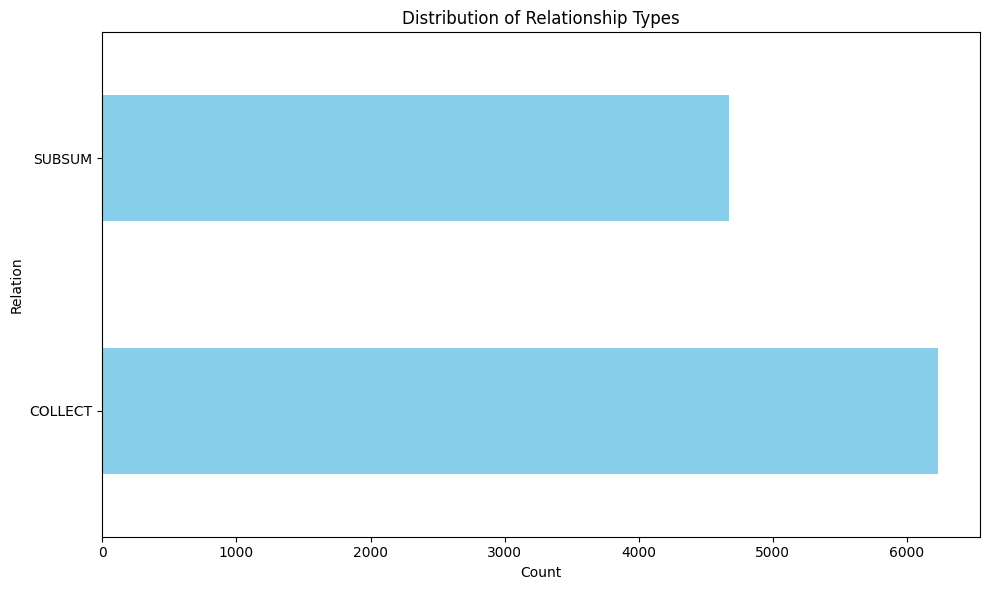

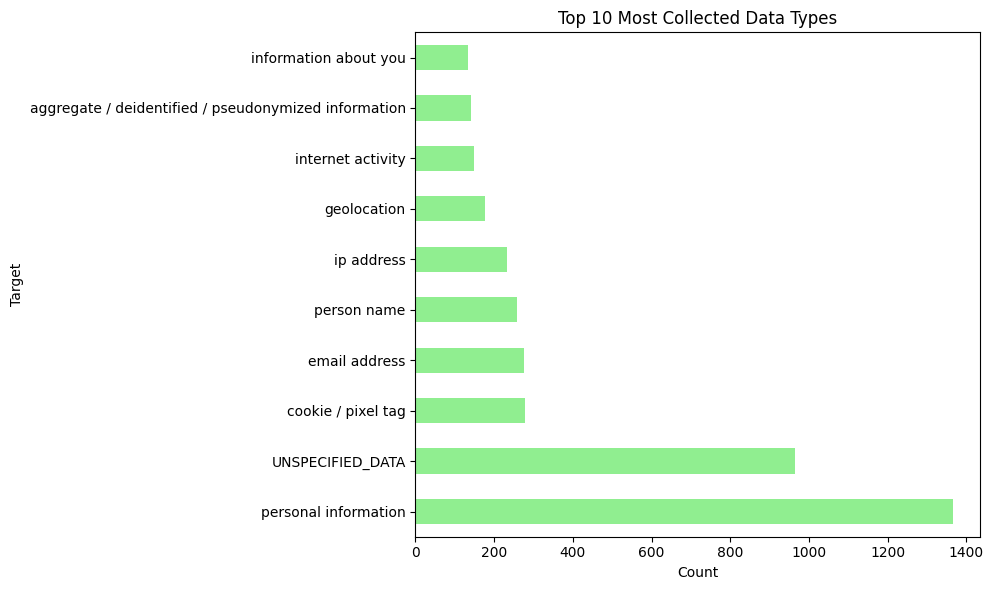

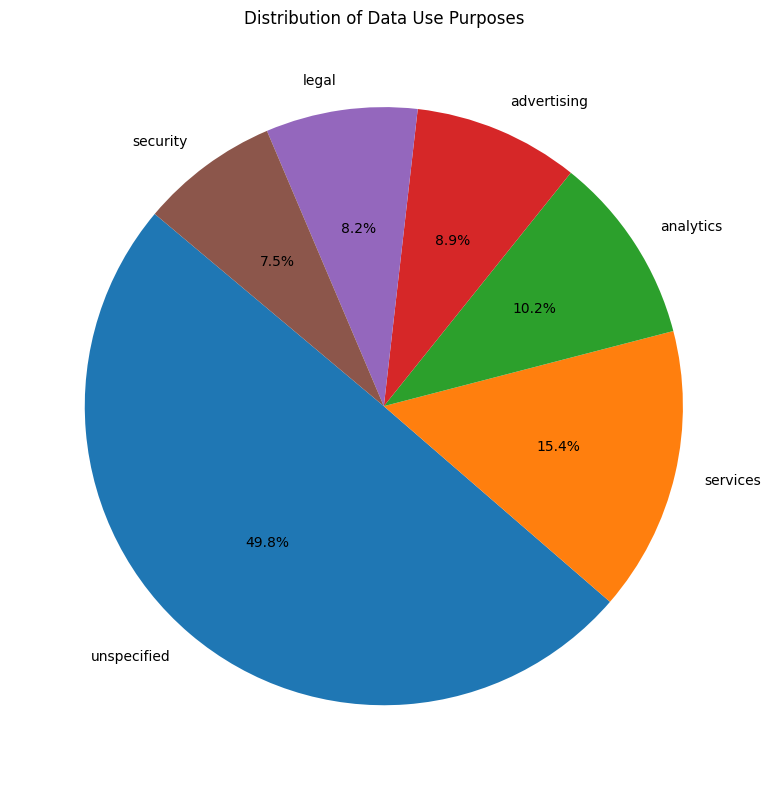

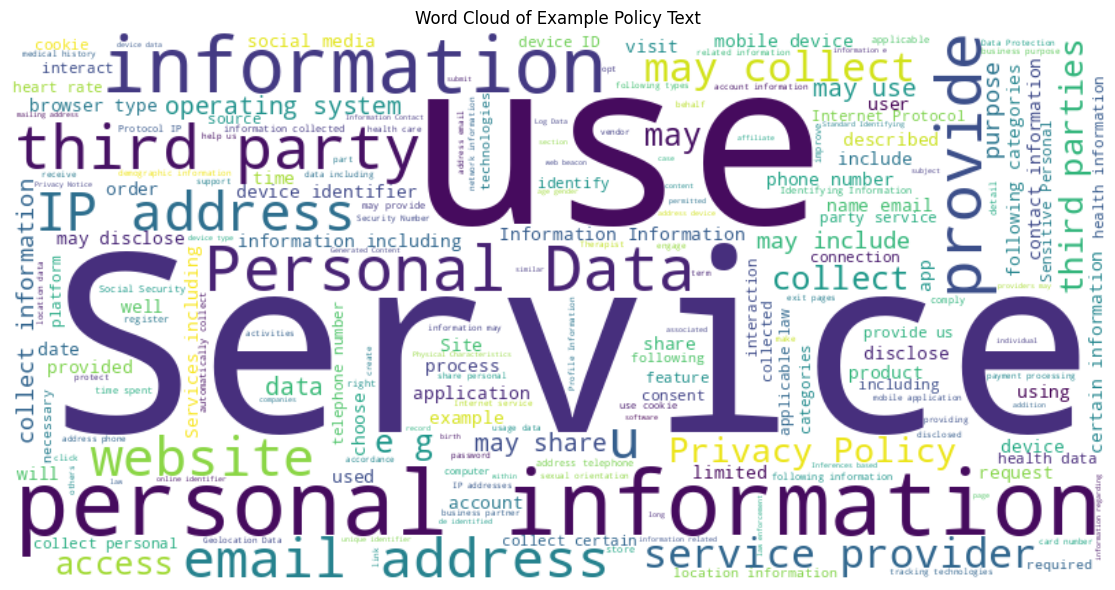


 Step 3: Clustering and Evaluation...


<ipython-input-9-4ec10a734acf>:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = cm.get_cmap('rainbow', num_clusters)


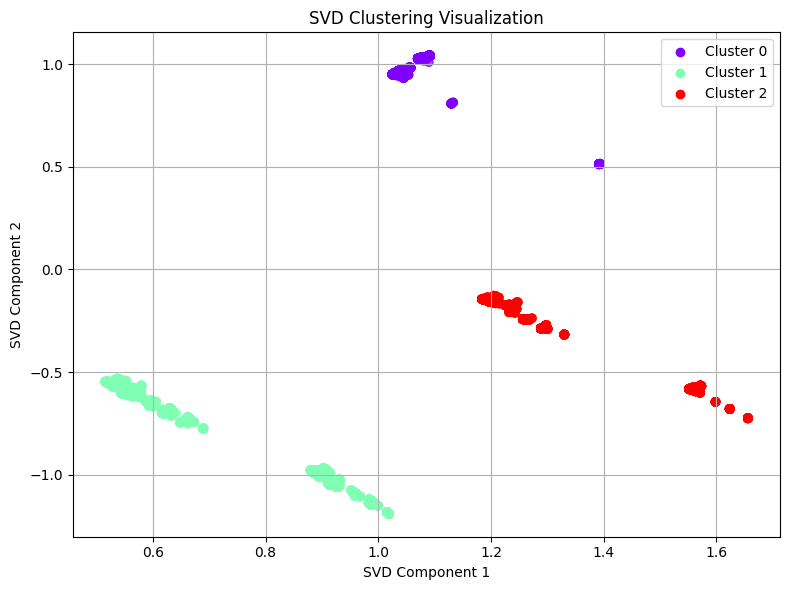

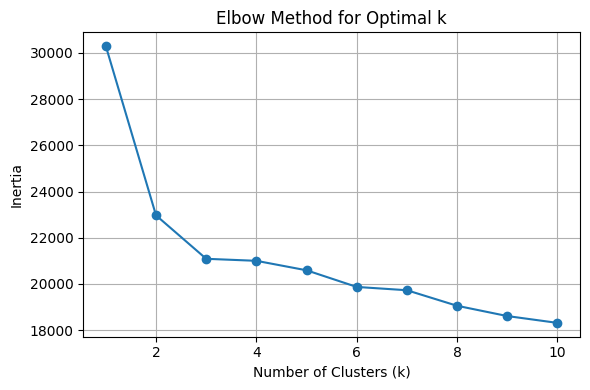

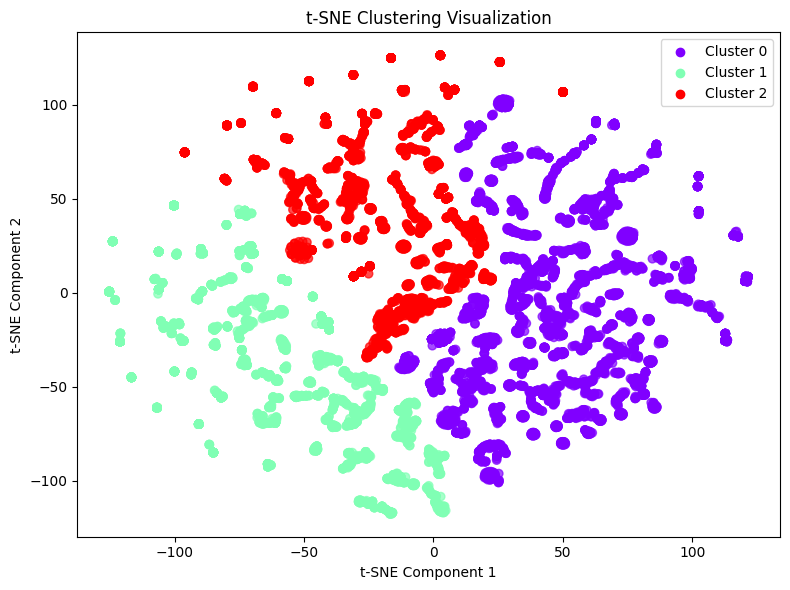

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: 

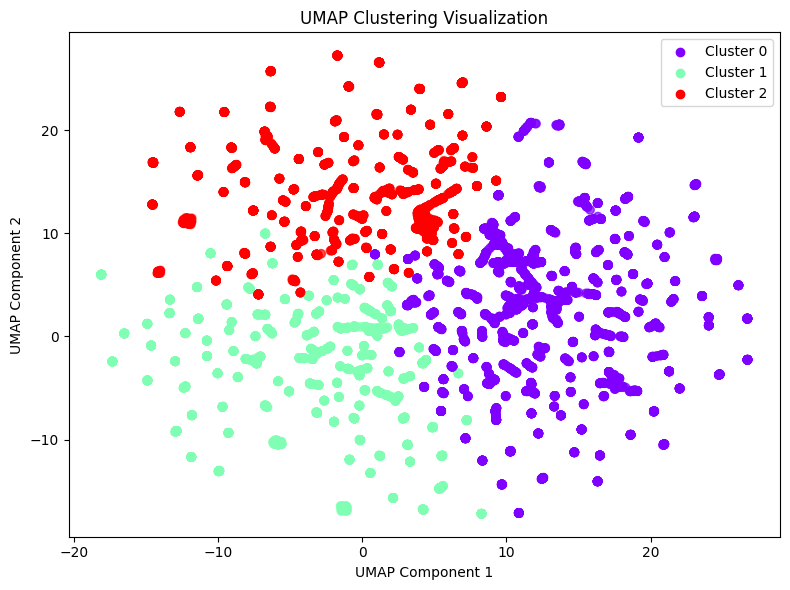


🔵 Cluster 0:
  Top Keywords (Target): ['person_name', 'email_address', 'ip_address', 'postal_address', 'phone_number']
  Top Purpose Category: unspecified
  Top Relation: SUBSUM
  Top Source: personal information

🔵 Cluster 1:
  Top Keywords (Target): ['personal_information', 'unspecified_data', '_pixel_tag', 'cookie_', 'information_about_you']
  Top Purpose Category: services
  Top Relation: COLLECT
  Top Source: we

🔵 Cluster 2:
  Top Keywords (Target): ['personal_information', 'unspecified_data', 'internet_activity', 'information_about_you', 'geolocation']
  Top Purpose Category: unspecified
  Top Relation: COLLECT
  Top Source: we


In [10]:

def main():
    print("Step 1: Transforming Graph YAML Files...")
    transform_graphs()
    print("\nStep 2: Performing Exploratory Data Analysis (EDA)...")
    perform_eda()
    print("\n Step 3: Clustering and Evaluation...")
    perform_clustering()

# Run the full pipeline
main()


## 🏁 7. Conclusion
- This notebook successfully demonstrates the end-to-end clustering pipeline on privacy policy data.
- Key insights are drawn from EDA and clustering analysis.
- Future work may explore additional clustering methods or deeper text analysis.